In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("dataset/url_features_extracted1.csv")

print(df.shape)
df.head()

(101219, 18)


,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,0.0
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,0.0
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,0.0
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,0.0


In [3]:
import re
import math
from urllib.parse import urlparse

def extract_features(url):
    parsed = urlparse(url)
    domain = parsed.netloc
    
    url_length = len(url)
    has_ip_address = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    dot_count = url.count('.')
    https_flag = 1 if parsed.scheme == 'https' else 0
    
    prob = [float(url.count(c)) / len(url) for c in set(url)]
    url_entropy = -sum([p * math.log2(p) for p in prob])
    
    tokens = re.split(r'[./?=&-]', url)
    token_count = len([t for t in tokens if t])
    
    parts = domain.split('.')
    subdomain_count = len(parts) - 2 if len(parts) > 2 else 0
    
    query_param_count = parsed.query.count('&') + (1 if parsed.query else 0)
    
    tld = parts[-1] if len(parts) > 0 else ''
    tld_length = len(tld)
    
    path_length = len(parsed.path)
    has_hyphen_in_domain = 1 if '-' in domain else 0
    
    number_of_digits = sum(c.isdigit() for c in url)
    
    popular_tlds = ['com','org','net','id','co']
    tld_popularity = 1 if tld in popular_tlds else 0
    
    suspicious_exts = ['.exe','.zip','.rar','.scr']
    suspicious_file_extension = 1 if any(url.endswith(ext) for ext in suspicious_exts) else 0
    
    domain_name_length = len(domain)
    percentage_numeric_chars = number_of_digits / len(url)
    
    return [
        url_length, has_ip_address, dot_count, https_flag, url_entropy,
        token_count, subdomain_count, query_param_count,
        tld_length, path_length, has_hyphen_in_domain, number_of_digits,
        tld_popularity, suspicious_file_extension,
        domain_name_length, percentage_numeric_chars
    ]

In [4]:
new_urls = [
"http://www.progarchives.com/album.asp?id=61737",
"http://signin.eday.co.uk.ws.edayisapi.dllsign.inusingsslpuseridcopartnerid2siteid.zdfxx949xyss1pnbh0soabfdzgdh2kppnu.reippl.com/",
"http://www.avevaconstruction.com/blesstool/image.htm",
"http://www.jp519.com/",
"https://www.velocidrone.com/",
"https://support-appleld.com.secureupdate.duilawyeryork.com/ap/b5aed586dda5d21/?cmd=_update&dispatch=b5aed586dda5d219f&locale=_US",
"https://www.authpro.com/auth/ubabankng/?action=reg",
"http://littlee.com.au/alibaba/login.alibaba.com.php",
"http://www.tutorialspoint.com/dbms/",
"http://www.domarada.sk",
"http://www.grouper.in/wp-includes/js/tinymce/etisalat.ae/",
"https://www.prepaid-karte-vergleich.de/",
"http://nandabolsas.com.br/forum/control.html",
"http://betasus7.blogspot.com",
"https://www.youtube.com/channel/UCLSjw7g5U48jgtjaeyjfwjQ",
"https://fieldstonerp-my.sharepoint.com/:b:/p/danfields/EZ7SH1xQSDpMtP4DleQT5tUBXo4sRqDgcRy807wUg7VFFg?e=Mz09kC",
"http://www.webopedia.com/TERM/C/CLI.html",
"https://www.allmenus.com/nc/charlotte/89187-mimosa-grill/menu/",
"http://www.makeuseof.com/tag/p2p-peer-peer-file-sharing-works/",
"http://bdo-onlineverify.xyz/bdoverification/security/verify/login.php",
"http://www.picfront.org/",
"http://kam-net.ci/2026584619/verification.php",
"https://www.beddenreus.nl/",
"https://www.simpsonbayresort.com/",
"http://hamathiel-sunsheer.tumblr.com",
"http://ipnpr.jpl.nasa.gov/progress_report/42-64/64G.PDF",
"https://www.powerhome.jp/",
"https://www.insidethefun.com/Login.aspx?redir=/default.aspx",
"http://whatsappporn.wikaba.com/",
"https://disq.us/?url=https%3A%2F%2Fwww.gepard.ru%2Flogin%2Faccount%2F&key=JgDq7zS0rAtd6srC39cdig",
"http://www.accaparlante.it/",
"https://www.learnnext.com/user/signUpNew.htm",
"https://www.megachords.com/gigi/chords/amnesia/",
"http://netizenbuzz.blogspot.com/",
"http://www.vagueware.com/proprietary-software/",
"http://learnmore.duke.edu/certificates/digital_marketing",
"https://doubler.link/",
"http://www.centcom.mil/ABOUT-US/COMMAND-NARRATIVE/",
"https://user67509874097802.el.r.appspot.com/app/index",
"https://client-webhook-dot-qp-keybank-rrva-2020-04.uc.r.appspot.com/",
"https://www.theswiftcodes.com/kenya/ninckena/",
"http://chat-whatsapp.ns01.us/",
"http://www.josuejr.com.br/glt/cgi/login.php?email=test@test.com",
"http://etigroup.az/wp-content/plugins/revslider/languages/o/indexaa.php",
"http://marketinghelper.com.au/themes/sports/wp-content/net/c74c4bf0dad9cbae3d80faa054b7d8ca/",
"https://form.elementform.com/0a4b86bcfd8d414b9fbce0329020508d45549925",
"https://uwwivwhdqgjrauuhsjnznfzjprsdvgaiyojw-dot-gl494903049.wl.r.appspot.com/",
"http://www.surfacespa.com/au/",
"http://www.myappwiz.com/home/redirect?targetUrl=http://5.83.162.160/staff",
"http://support-appleld.com.secureupdate.duilawyeryork.com/ap/7a2a8f1e1c7c105/?cmd=_update&dispatch=7a2a8f1e1c7c105b9&locale=_US",
"http://www.partycity.com/category/party+ideas/birthday/boys/mickey+mouse.do",
"https://kodi.tv/addons/context-menus",
"https://www.virzoom.com/",
"https://en.wikipedia.org/wiki/Switched_at_Birth_(season_5)",
"https://docs.google.com/forms/d/e/1FAIpQLSfDwn92QVW38Ss-20KziPdDCTGi6S6IH4nAsXeQlGTvdjh4eA/closedform",
"http://blog.unibulmerchantservices.com/credit-card-transaction-processing-basics/",
"https://forms.office.com/Pages/ResponsePage.aspx?id=DQSIkWdsW0yxEjajBLZtrQAAAAAAAAAAAAN__iRYFuZURVNGMFBTVDZFMjFGUFhVWkM3RzZaR1JVNS4u",
"http://fastfoodgozo.rs/a/yahoo/login.php",
"http://sucursalpersonastransaccionesbancolombiacom.small-business-solutions.biz/",
"http://www.vantaiduccuong.com/dab/outl/",
"http://scqijie.com/wp-content/themes/chigue/immowelt.de-sign-in",
"http://www.japanese-buddhism.com/noble-eightfold-path.html",
"https://for-sale.yakaz.com/digital-cameras",
"http://dgfhjgjrt65756hggree.clearpointsupplies.com/fhdfyrurthftf/",
"https://servicefacture.blogspot.com/2020/04/blog-post_10.html",
"http://grandmarketltd.co.uk/wp-includes/inozfoZ/noande/paypal/59c0d7ceb90328d92e80f4e1f3646b99/view/login.php",
"http://teamwlg.com/aa209Page/aa209Page/cmd-login=2fa960a1990a231b18bfe6368da9c911/valid.php?email=",
"http://biddle-air.co.uk",
"https://tlcmgmt-my.sharepoint.com/",
"https://www.ademforcongress.com/",
"https://edu-src.msu.ac.th/clinic/wp-includes/rest-api/fields/--/pontosvalidos/home.php",
"http://www.nationsonline.org/oneworld/map/google_map_Nice.htm",
"http://www.innovativephp.com/",
"http://surfeventsco.com/cgi-/",
"http://www.thefreedictionary.com/active+transport",
"https://helpathome.jobs.net/",
"https://hoosevents.com/https:/impotsgouvfr/",
"https://dpfoidspoifopdsifpoi.blogspot.com/",
"https://chungcuvinhomessmartcity.com.vn/wp-content/t-online/t-online.php",
"https://www.scubaearth.com/",
"http://www.cndoubleegret.com/admin/secure/cmd-login=8e624428269b1e296f49085bd6b42d28/",
"http://www.yourdictionary.com/legislative-session",
"https://bbvaconsultas.com/",
"https://ocurenc.com/",
"https://www.helloprint.nl/",
"https://www.portablefreeware.com/",
"http://www.weightgaintruth.com/",
"http://www.goodhopeservices.com/update/",
"http://www.landscape-design-advisor.com/",
"https://billingservice-ee.com/account/index",
"http://apple.com.aieuv.cn/mim/4u220j18s43i590rr8485m4e85v375gbm903392982898s7926.html",
"http://outlook-webapp-portal.el.r.appspot.com/wp-content/xp.php",
"https://seconfin.com/ab/CNC/en.php",
"http://updatequota.byethost5.com/form.php",
"https://www.officialliker.co/",
"http://www.abdnepal.com/etigrade/ebill/login.php",
"http://www.tucontaweb.com/Nachprufung",
"http://assembly.ca.gov/committees",
"https://www.hyperride.co.nz/",
"https://tools.ietf.org/html/1459",
"https://www.iptvultra.com/",
"http://secureupdate.appleld.com.duilawyeryork.com/",
"http://78.143.96.35/wordpress/gam/index.php",
"https://www.youtube.com/watch?v=HlsHu9aD9_s",
"https://www.marsbahis234.com/tr/",
"http://jmockit.github.io",
"https://www.all-about-psychology.com/",
"https://rainbow-walker.com/",
"http://pixel.baltic-dragon.ru/",
"https://www.nuix.com/",
"http://www.homeandlearn.org/open_a_text_file_in_vba.html",
"http://iflix.top",
"https://www.sejapremium.com.br/",
"http://twowheelcool.com/twitter.com/login9ed2.html",
"http://informacje24-alert.eu/weryfikacja/mobile",
"https://www.youtube.com/user/VoltaireMusicPage",
"https://bankcampuscareers.tal.net/",
"https://www.npmjs.com/node-red",
"http://piripiriormskirk.co.uk",
"http://bbgeeks.com/.f/",
"http://resources.infosecinstitute.com/session-hijacking-cheat-sheet/",
"http://www.contextures.com/excelhyperlinkfunction.html",
"http://www.mutuo.it",
"http://www.Cisco.com/c/en/us/support/docs/security/"
]

In [5]:
labels = []

for url in new_urls:
    u = url.lower()
    
    if (
        any(x in u for x in [
            "login","verify","update","secure","account","bank",
            "paypal","signin","wp-admin","cmd","token","auth",
            "webscr","redirect","confirm","password"
        ])
        or len(u) > 100
        or u.count('.') > 5
        or any(x in u for x in ["@", "%", "&", "="])
        or any(x in u for x in ["-dot-", "appspot", "blogspot"])
        or any(x in u for x in ["apple", "paypal", "bank", "google"]) and ".com" not in u.split("/")[2]
    ):
        labels.append(0)  # phishing
    else:
        labels.append(1)  # legitimate

In [6]:
new_data = []

for url, label in zip(new_urls, labels):
    features = extract_features(url)
    
    row = features + [label]
    new_data.append(row)

columns = [
    "url_length","has_ip_address","dot_count","https_flag","url_entropy",
    "token_count","subdomain_count","query_param_count",
    "tld_length","path_length","has_hyphen_in_domain","number_of_digits",
    "tld_popularity","suspicious_file_extension",
    "domain_name_length","percentage_numeric_chars","ClassLabel"
]

new_df = pd.DataFrame(new_data, columns=columns)

new_df.head()

,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,46,0,3,0,4.615422,8,1,1,3,10,0,5,1,0,20,0.108696,0
1,128,0,10,0,4.568665,12,9,0,3,1,0,7,1,0,120,0.054688,0
2,52,0,3,0,4.192678,7,1,0,3,20,0,0,1,0,25,0.000000,1
3,21,0,2,0,3.653757,4,1,0,3,1,0,3,1,0,13,0.142857,1
4,28,0,2,1,4.012188,4,1,0,3,1,0,0,1,0,19,0.000000,1


In [7]:
df_updated = pd.concat([df, new_df], ignore_index=True)

print("Sebelum:", df.shape)
print("Sesudah:", df_updated.shape)

Sebelum: (101219, 18)
Sesudah: (101343, 18)


In [9]:
df_updated.to_csv("dataset/dataset_updated.csv", index=False)

In [12]:
import pandas as pd

df = pd.read_csv("dataset/dataset_updated.csv")

# ❗ DROP URL (PENTING)
df = df.drop(columns=["URL"])

# cek
print(df.head())

   url_length  has_ip_address  dot_count  https_flag  url_entropy  \
0          47               0          2           1     4.250669   
1          40               0          2           1     4.196439   
2          23               0          1           0     3.936180   
3          30               0          1           0     3.894740   
4          47               0          1           1     4.143127   

   token_count  subdomain_count  query_param_count  tld_length  path_length  \
0            6                1                  1           3            1   
1            6                1                  1           3            1   
2            5                0                  1           2            1   
3            5                0                  1           3            1   
4            7                0                  1           3           18   

   has_hyphen_in_domain  number_of_digits  tld_popularity  \
0                     1                 0        

In [13]:
X = df.drop("ClassLabel", axis=1)
y = df["ClassLabel"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
print(df["ClassLabel"].isna().sum())

1


In [18]:
df = df.dropna(subset=["ClassLabel"])

In [19]:
df = df.reset_index(drop=True)

In [21]:
print(y_test.isna().sum())

1


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ======================
# LOAD DATA
# ======================
df = pd.read_csv("dataset/dataset_updated.csv")

# DROP URL
df = df.drop(columns=["URL"])

# HAPUS NaN (WAJIB)
df = df.dropna()

# CEK
print("NaN di dataset:", df.isna().sum().sum())

# ======================
# SPLIT
# ======================
X = df.drop("ClassLabel", axis=1)
y = df["ClassLabel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# MODEL
# ======================
model = RandomForestClassifier()
model.fit(X_train, y_train)

# ======================
# EVALUASI
# ======================
print("Accuracy:", model.score(X_test, y_test))

NaN di dataset: 0
Accuracy: 0.9991119443485125


In [26]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

In [28]:
lr = LogisticRegression(max_iter=1000)

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("CV Mean:", scores.mean())

CV Mean: 0.991632483885114


In [30]:
for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    print(f"\n{name}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)


Decision Tree
Train Accuracy: 0.9961269473190828
Test Accuracy : 0.9965957866692979

Random Forest
Train Accuracy: 0.9997656433091164
Test Accuracy : 0.9991612807735951

Logistic Regression
Train Accuracy: 0.996151616444439
Test Accuracy : 0.9955597217425626


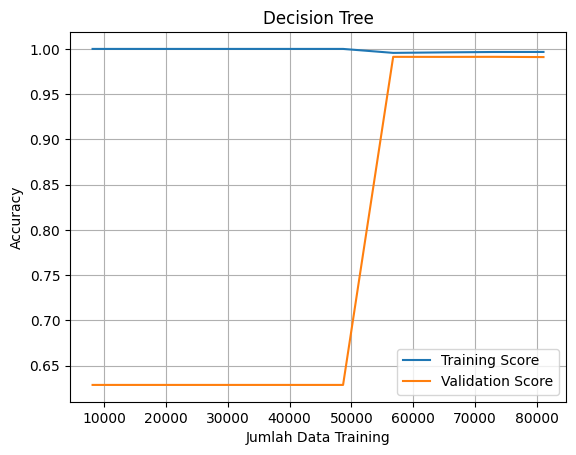

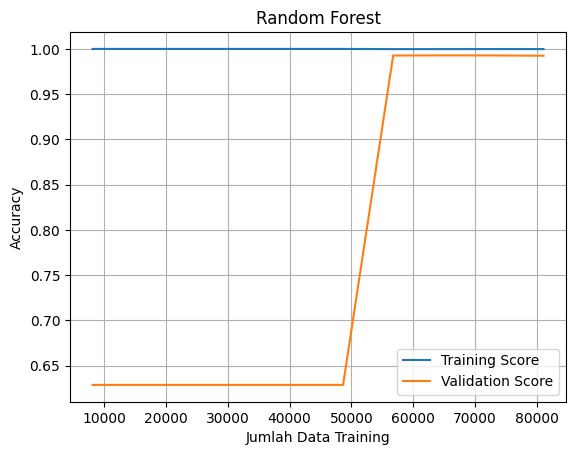

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\AppData\Lo

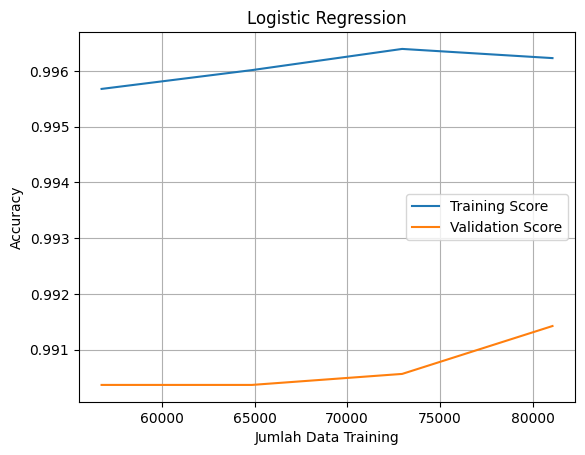

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# =========================
# MODEL
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# =========================
# FUNCTION PLOT
# =========================
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(title)
    plt.xlabel("Jumlah Data Training")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()


# =========================
# RUN SEMUA MODEL
# =========================
for name, model in models.items():
    plot_learning_curve(model, X, y, name)

In [32]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import joblib

# misal model terbaik kamu Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)

# simpan model
joblib.dump(model, "model/rf_modelnew.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [24]:
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# =========================
# 1. LOAD & CLEAN DATA
# =========================
df = pd.read_csv("dataset/dataset_updated.csv")

# DROP URL (WAJIB)
if "URL" in df.columns:
    df = df.drop(columns=["URL"])

# HAPUS NaN
df = df.dropna().reset_index(drop=True)

print("Total data:", len(df))
print("Cek NaN:", df.isna().sum().sum())

# =========================
# 2. SPLIT DATA
# =========================
X = df.drop("ClassLabel", axis=1)
y = df["ClassLabel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. DEFINISI MODEL
# =========================
dt = DecisionTreeClassifier(max_depth=5)
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
lr = LogisticRegression(max_iter=1000)

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}

results = {}

# =========================
# 4. TRAIN & EVALUASI
# =========================
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # TRAIN
    model.fit(X_train, y_train)
    
    # PREDIKSI
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # METRICS
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    # PRINT
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-Score :", f1)
    print("ROC-AUC  :", roc)
    print("Confusion Matrix:\n", cm)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # SIMPAN HASIL
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc
    }

# =========================
# 5. CROSS VALIDATION
# =========================
print("\n===== CROSS VALIDATION =====")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Mean: {scores.mean()}")

# =========================
# 6. PILIH MODEL TERBAIK
# =========================
best_model_name = max(results, key=lambda x: results[x]["roc_auc"])
best_model = results[best_model_name]["model"]

print(f"\n🔥 Best Model: {best_model_name}")

# =========================
# 7. SIMPAN MODEL
# =========================
os.makedirs("model", exist_ok=True)

# simpan model
with open("model/phishing_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# simpan nama fitur (WAJIB untuk web)
with open("model/feature_columns.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print("✅ Model berhasil disimpan!")

Total data: 101342
Cek NaN: 0

===== Decision Tree =====
Accuracy : 0.9965957866692979
Precision: 0.9969123372264733
Recall   : 0.9938436830835118
F1-Score : 0.9953756450640038
ROC-AUC  : 0.9999460829952282
Confusion Matrix:
 [[12774    23]
 [   46  7426]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12797
         1.0       1.00      0.99      1.00      7472

    accuracy                           1.00     20269
   macro avg       1.00      1.00      1.00     20269
weighted avg       1.00      1.00      1.00     20269


===== Random Forest =====
Accuracy : 0.9991612807735951
Precision: 0.9994640225110545
Recall   : 0.9982601713062098
F1-Score : 0.998861734181453
ROC-AUC  : 0.9999902634601022
Confusion Matrix:
 [[12793     4]
 [   13  7459]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12797
         1.0       1.00      1.00

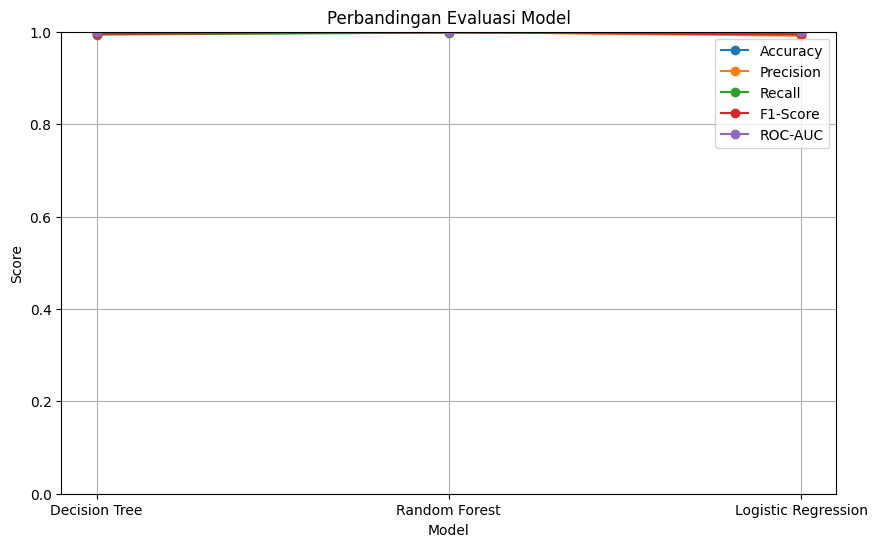

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_names = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
roc_list = []

# pastikan model sudah di-fit sebelumnya!
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    model_names.append(name)
    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))
    roc_list.append(roc_auc_score(y_test, y_prob))

# =========================
# PLOT GRAFIK GARIS
# =========================
plt.figure(figsize=(10,6))

plt.plot(model_names, accuracy_list, marker='o', label='Accuracy')
plt.plot(model_names, precision_list, marker='o', label='Precision')
plt.plot(model_names, recall_list, marker='o', label='Recall')
plt.plot(model_names, f1_list, marker='o', label='F1-Score')
plt.plot(model_names, roc_list, marker='o', label='ROC-AUC')

plt.title("Perbandingan Evaluasi Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid()

plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9991612807735951


In [35]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# save model (PASTIKAN INI MODEL)
joblib.dump(model, "model/rf_modelnewnew.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [36]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, "model/feature_names.pkl")

['model/feature_names.pkl']

In [ ]:
import joblib

model = joblib.load("model/rf_modelnewnew.pkl")
feature_names = joblib.load("model/feature_names.pkl")